In [ ]:
!pip install kaggle opencv-python-headless tensorflow scikit-learn matplotlib

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anthonya6983","key":"53b7f029c9ea84bfca3b683ba037967d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/breast-histopathology-images

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.10G/3.10G [02:31<00:00, 21.9MB/s]



In [ ]:
!unzip breast-histopathology-images.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1551_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1601_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1651_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1701_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1751_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1801_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1851_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1901_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1951_class0.png  
  inflating: /content/data/IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y2001_class0.png  
  inflating: /content/data/IDC_regular_

In [ ]:
import os
import shutil

source = "/content/data/IDC_regular_ps50_idx5"
destination = "/content/data/IDC_binary"

os.makedirs(os.path.join(destination, "0"), exist_ok=True)
os.makedirs(os.path.join(destination, "1"), exist_ok=True)

for patient in os.listdir(source):

    patient_path = os.path.join(source, patient)

    if not os.path.isdir(patient_path):
        continue

    for label in ["0", "1"]:

        label_path = os.path.join(patient_path, label)

        if os.path.exists(label_path):

            for image in os.listdir(label_path):

                shutil.copy(
                    os.path.join(label_path, image),
                    os.path.join(destination, label, image)
                )

print("Dataset organized successfully.")

Dataset organized successfully.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [ ]:
IMG_SIZE = (128,128)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_gen = datagen.flow_from_directory(
    "/content/data/IDC_binary",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "/content/data/IDC_binary",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 222020 images belonging to 2 classes.
Found 55504 images belonging to 2 classes.


In [ ]:
print(train_gen.class_indices)

{'0': 0, '1': 1}


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = tf.keras.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
history = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=3

)

Epoch 1/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 343s 47ms/step - accuracy: 0.8435 - loss: 0.3648 - val_accuracy: 0.8236 - val_loss: 0.3963
Epoch 2/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 224s 32ms/step - accuracy: 0.8548 - loss: 0.3419 - val_accuracy: 0.8300 - val_loss: 0.3923
Epoch 3/3
6939/6939 ━━━━━━━━━━━━━━━━━━━━ 215s 31ms/step - accuracy: 0.8588 - loss: 0.3338 - val_accuracy: 0.8237 - val_loss: 0.3980


In [ ]:
loss, accuracy = model.evaluate(val_gen)

print("Loss:", loss)
print("Accuracy:", accuracy)

1735/1735 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8237 - loss: 0.3980
Loss: 0.3979894816875458
Accuracy: 0.8236523270606995


In [ ]:
val_gen.reset()

predictions = model.predict(val_gen)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = val_gen.classes

1735/1735 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step


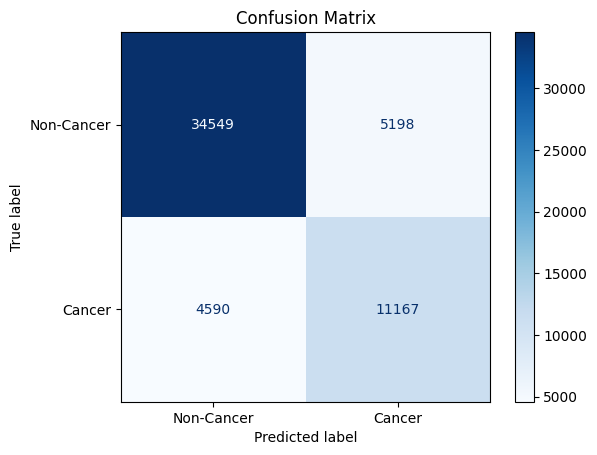

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Cancer","Cancer"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

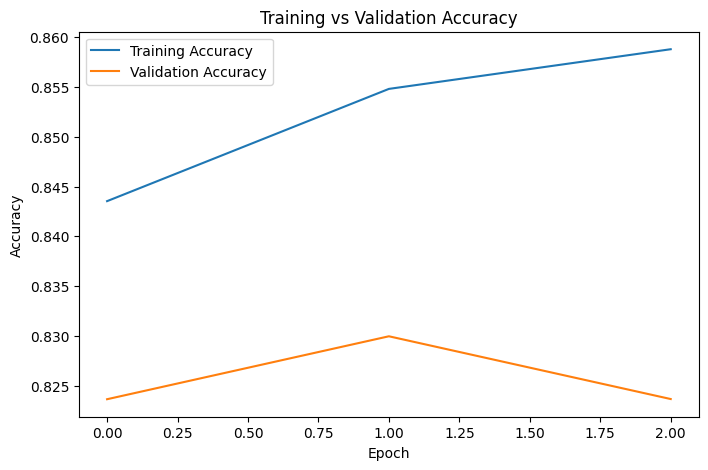

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

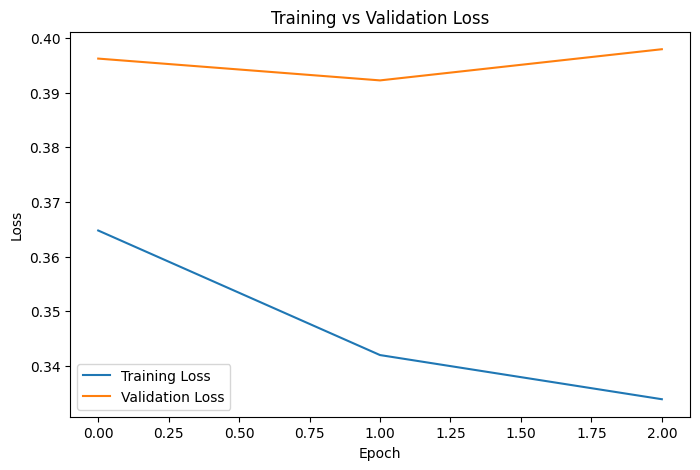

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

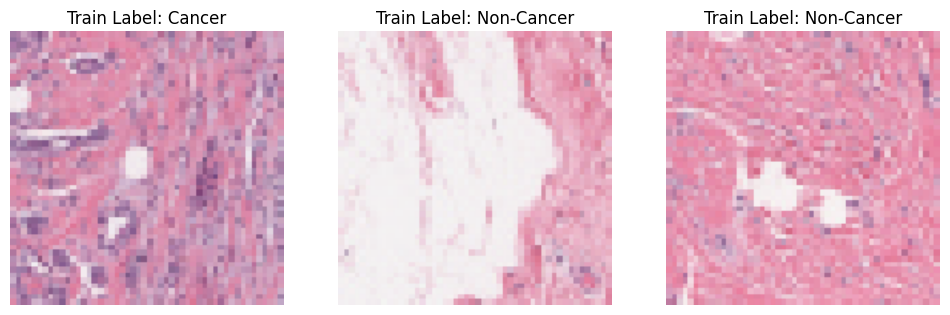

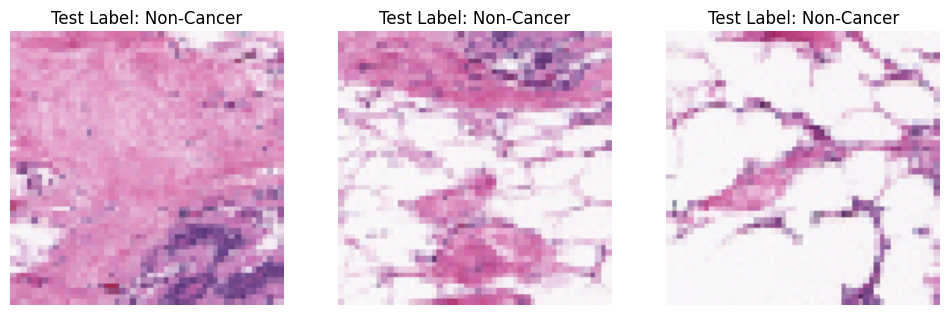

In [ ]:
import matplotlib.pyplot as plt

# Label mapping
class_names = {
    0: "Non-Cancer",
    1: "Cancer"
}

# Get one batch from the training generator
train_images, train_labels = next(train_gen)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(train_images[i])
    plt.title(f"Train Label: {class_names[int(train_labels[i])]}")
    plt.axis('off')
plt.show()

# Get one batch from the validation/test generator
val_images, val_labels = next(val_gen)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(val_images[i])
    plt.title(f"Test Label: {class_names[int(val_labels[i])]}")
    plt.axis('off')
plt.show()

In [ ]:
print(classification_report(

    true_classes,

    predicted_classes,

    target_names=["Non-Cancer","Cancer"]

))


              precision    recall  f1-score   support

  Non-Cancer       0.88      0.87      0.88     39747
      Cancer       0.68      0.71      0.70     15757

    accuracy                           0.82     55504
   macro avg       0.78      0.79      0.79     55504
weighted avg       0.83      0.82      0.82     55504



Use yolo to compare the dataset evaluations  make the 0 and 1 say cancer or non cancer


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolo11n-cls.pt")

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if len(dirs):
        print(root)

/content
/content/.config
/content/.config/logs
/content/data
/content/data/13688
/content/data/12893
/content/data/16534
/content/data/12886
/content/data/12933
/content/data/16555
/content/data/12750
/content/data/9178
/content/data/12626
/content/data/14079
/content/data/12879
/content/data/13402
/content/data/15516
/content/data/14156
/content/data/14209
/content/data/8957
/content/data/12748
/content/data/9023
/content/data/9041
/content/data/8867
/content/data/10301
/content/data/10254
/content/data/13403
/content/data/8913
/content/data/15472
/content/data/9075
/content/data/12868
/content/data/8918
/content/data/8916
/content/data/16531
/content/data/12900
/content/data/9228
/content/data/13106
/content/data/13019
/content/data/9383
/content/data/13691
/content/data/10299
/content/data/12881
/content/data/10306
/content/data/15473
/content/data/IDC_regular_ps50_idx5_split
/content/data/IDC_regular_ps50_idx5_split/val
/content/data/IDC_regular_ps50_idx5_split/train
/content/data

In [ ]:
results = model.train(
    data="/content/data/IDC_binary",
    epochs=3,
    imgsz=224,
    batch=32,
    device=0,
    project="YOLO_Project",
    name="YOLO11_BreastCancer"
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/IDC_binary, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11_BreastCancer-8, nbs=64, nms=False, opset=None, 

In [ ]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/data/IDC_binary/train
Found 277524 images in subdirectories. Attempting to split...
Splitting /content/data/IDC_binary (2 classes, 277524 images) into 80% train, 20% val...
Split complete in /content/data/IDC_binary_split ✅
train: /content/data/IDC_binary_split/train... found 275310 images in 2 classes ✅ 
val: /content/data/IDC_binary_split/val... found 135513 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 220.3±169.6 MB/s, size: 5.9 KB)
val: Scanning /content/data/IDC_binary_split/val... 135323 images, 190 corrupt: 100% ━━━━━━━━━━━━ 135513/135513 2.7Kit/s 50.1s
val: /content/data/IDC_binary_split/val/0/10273_idx5_x1001_y2451_class0.png: ignoring corrupt image/label: image size (3, 50) <10 pixels
val: /content/data/IDC_binary

In [ ]:
best_model = YOLO(
    "/content/runs/classify/YOLO_Project/YOLO11_BreastCancer-8/weights/best.pt"
)

In [ ]:
import os

test_path = "/content/data/IDC_binary_split/val"

true_labels = []
predicted_labels = []

count = 0

for class_index, class_name in enumerate(["0", "1"]):

    folder = os.path.join(test_path, class_name)

    for image in os.listdir(folder):

        image_path = os.path.join(folder, image)

        prediction = best_model.predict(
            image_path,
            verbose=False
        )

        predicted = int(prediction[0].probs.top1)

        true_labels.append(class_index)
        predicted_labels.append(predicted)

        count += 1

        if count % 100 == 0:
            print(f"Processed {count} images")

Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Processed 700 images
Processed 800 images
Processed 900 images
Processed 1000 images
Processed 1100 images
Processed 1200 images
Processed 1300 images
Processed 1400 images
Processed 1500 images
Processed 1600 images
Processed 1700 images
Processed 1800 images
Processed 1900 images
Processed 2000 images
Processed 2100 images
Processed 2200 images
Processed 2300 images
Processed 2400 images
Processed 2500 images
Processed 2600 images
Processed 2700 images
Processed 2800 images
Processed 2900 images
Processed 3000 images
Processed 3100 images
Processed 3200 images
Processed 3300 images
Processed 3400 images
Processed 3500 images
Processed 3600 images
Processed 3700 images
Processed 3800 images
Processed 3900 images
Processed 4000 images
Processed 4100 images
Processed 4200 images
Processed 4300 images
Processed 4400 images
Processed 4500 images
Processed 4600 imag

In [ ]:
accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(f"YOLO Accuracy: {accuracy:.4f}")

YOLO Accuracy: 0.9014


In [ ]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

  Non-Cancer       0.94      0.92      0.93     97011
      Cancer       0.81      0.86      0.83     38502

    accuracy                           0.90    135513
   macro avg       0.87      0.89      0.88    135513
weighted avg       0.90      0.90      0.90    135513



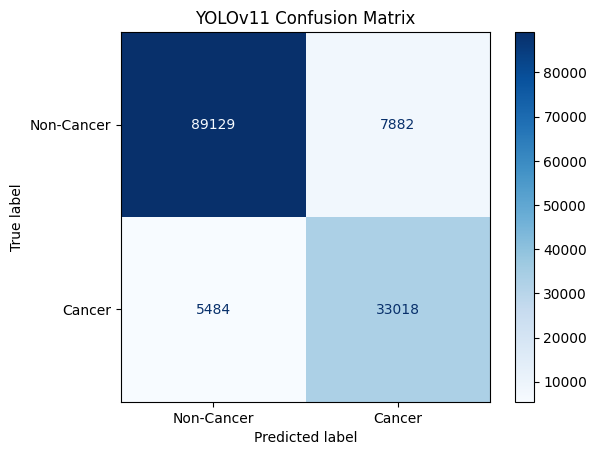

In [ ]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("YOLOv11 Confusion Matrix")
plt.show()

In [ ]:
mobilenet_accuracy = 0.8236523270606995
yolov11_accuracy = accuracy

comparison = pd.DataFrame({
    "Model": [
        "MobileNetV2",
        "YOLOv11"
    ],
    "Accuracy": [
        mobilenet_accuracy,
        yolov11_accuracy
    ]
})

comparison

,Model,Accuracy
0,MobileNetV2,0.823652
1,YOLOv11,0.901367


         Model  Accuracy  Precision  Recall  F1 Score
0  MobileNetV2  0.823652       0.83    0.82      0.82
1      YOLOv11  0.901367       0.90    0.90      0.90


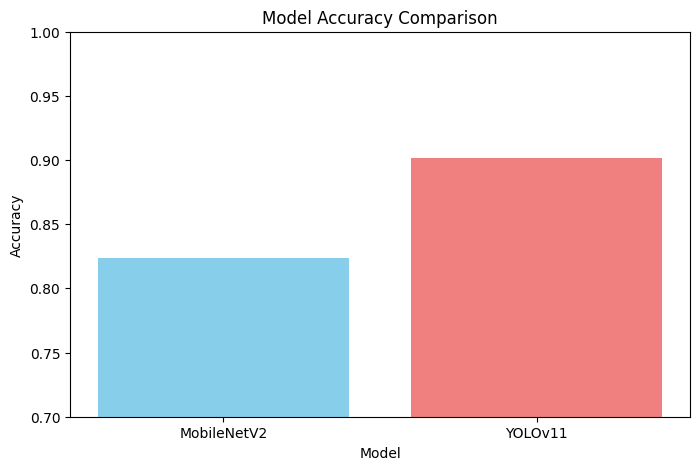

In [ ]:
mobilenet_accuracy = 0.8236523270606995
yolov11_accuracy = accuracy

mobilenet_precision = 0.83 # Weighted average from classification report
yolov11_precision = 0.90 # Weighted average from classification report

mobilenet_recall = 0.82 # Weighted average from classification report
yolov11_recall = 0.90 # Weighted average from classification report

mobilenet_f1 = 0.82 # Weighted average from classification report
yolov11_f1 = 0.90 # Weighted average from classification report

comparison = pd.DataFrame({

    "Model":[
        "MobileNetV2",
        "YOLOv11"
    ],

    "Accuracy":[
        mobilenet_accuracy,
        yolov11_accuracy
    ],

    "Precision":[
        mobilenet_precision,
        yolov11_precision
    ],

    "Recall":[
        mobilenet_recall,
        yolov11_recall
    ],

    "F1 Score":[
        mobilenet_f1,
        yolov11_f1
    ]

})

print(comparison)

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Accuracy"], color=['skyblue', 'lightcoral'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.show()